# DS207 Final Project - Predicting Readmission Rate for Diabetic Patients Using Machine Learning
#### Contributor: Rahil Sharma (rahilsharma@berkeley.edu)

### Notebook Structure:

1. Data Processing:
2. Baseline Model:
    * Majority
    * Multiclass Logistic Regression
3. Notebook Exports:
    * Datasets: `results/train.csv`, `results/val.csv`, and `results/test.csv`
    * Baseline model: in `baseline.pkl`

## 1. Data Processing

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import joblib
from matplotlib import pyplot as plt

import tensorflow as tf
from tensorflow import keras
import keras_tuner as kt
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report


In [2]:
df = pd.read_csv('../data/diabetic_data.csv')
raw_df = pd.read_csv('../data/diabetic_data.csv')
display(df.head())

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


### Key for Drug descriptions ##

Up: The dosage of the drug was increased for the patient during their encounter.

Down: The dosage was decreased.

Steady: The patient is on the drug, and the dosage was not changed.

No: The patient was not prescribed this specific drug.

In [3]:
print(f"There are {len(df.columns)} columns:\n", df.columns)

There are 50 columns:
 Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')


#### Drop duplicates and unnecessary columns

In [4]:
df = df.drop_duplicates(subset=['patient_nbr'], keep='first')

In [5]:
# checking to see how many missing values there are
(df == '?').sum()

# columns to keep based on descriptions / number of missing values
  # race (split into indicator variables)
  # gender (split into indicator variables)
  # age (split into indicator variables)
  # time_in_hospital (int)
  # num_lab_procedures (int)
  # num_procedures (int)
  # num_medications (int)
  # number_outpatient (int)
  # number_emergency (int)
  # number_inpatient (int)
  # number_diagnoses (int)
  # keeping all the indicator variables for medication / medication changes
  # target - multiclass classification

# dropping the unnecessary columns
df = df.drop(columns=['encounter_id', 'patient_nbr', 'weight', 'admission_type_id',
                      'discharge_disposition_id', 'admission_source_id', 'payer_code',
                      'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum',
                      'A1Cresult'],
             axis=1)

#### Collapse age and race

In [6]:
# Convert age buckets like "[70-80)" to numeric midpoint (75)
def age_to_mid(age_bucket):
    if pd.isna(age_bucket):
        return np.nan
    try:
        lo, hi = age_bucket.strip('[]').split('-')
        lo = int(lo)
        hi = int(hi.strip(')'))
        return (lo + hi) / 2
    except Exception:
        return np.nan
df['age_mid'] = df['age'].apply(age_to_mid)
df.drop(columns=['age'], inplace=True)

In [7]:
# Collapse low count race categories into 'Other'
if 'race' in df.columns:
    df['race'] = df['race'].fillna('Unknown')
    top = df['race'].value_counts().nlargest(4).index
    df['race_collapsed'] = df['race'].where(df['race'].isin(top), other='Other')
    df.drop(columns=['race'], inplace=True)

#### Categorical Features

In [8]:
# creating indicator variables for the categorical features (one-hot encoding)
df = pd.get_dummies(df, columns=['race_collapsed', 'gender'], dtype=int)

# Encode ordinal values according to the prescription status of the visit
prescription_map = {'No': 0,       # The drug was not prescribed
                    'Down': 1,     # The dosage was decreased
                    'Steady': 2,   # The dosage did not change
                    'Up': 3}       # The dosage was increased during the encounter
cat_columns = ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
               'glimepiride', 'acetohexamide', 'glipizide', 'glyburide',
               'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
               'miglitol', 'troglitazone', 'tolazamide', 'examide',
               'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin',
               'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone']
for cat_col in cat_columns:
    df[cat_col] = df[cat_col].map(prescription_map)

#### Binary features and Outcome of Interest

In [9]:
# displaying the data
print("The number of columns are: ", len(df.columns))
display(df.head())
print(df.columns)

# recoding change and diabetesMed to 0 for No and 1 to Yes
df['change'] = np.where(df['change'] == 'No', 0, 1)
df['diabetesMed'] = np.where(df['diabetesMed'] == 'No', 0, 1)

# mapping the target into three classes
readmission_map = {
    'NO': 0,  # no readmission recorded
    '>30': 0, # readmitted (over 30 days)
    '<30': 1  # readmitted (within 30 days)
}

df['readmitted'] = df['readmitted'].map(readmission_map)

display(df.head())

df['readmitted'].value_counts()


The number of columns are:  43


,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,metformin,repaglinide,...,readmitted,age_mid,race_collapsed_?,race_collapsed_AfricanAmerican,race_collapsed_Caucasian,race_collapsed_Hispanic,race_collapsed_Other,gender_Female,gender_Male,gender_Unknown/Invalid
0,1,41,0,1,0,0,0,1,0,0,...,NO,5.0,0,0,1,0,0,1,0,0
1,3,59,0,18,0,0,0,9,0,0,...,>30,15.0,0,0,1,0,0,1,0,0
2,2,11,5,13,2,0,1,6,0,0,...,NO,25.0,0,1,0,0,0,1,0,0
3,2,44,1,16,0,0,0,7,0,0,...,NO,35.0,0,0,1,0,0,0,1,0
4,1,51,0,8,0,0,0,5,0,0,...,NO,45.0,0,0,1,0,0,0,1,0


Index(['time_in_hospital', 'num_lab_procedures', 'num_procedures',
       'num_medications', 'number_outpatient', 'number_emergency',
       'number_inpatient', 'number_diagnoses', 'metformin', 'repaglinide',
       'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide',
       'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone',
       'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide',
       'examide', 'citoglipton', 'insulin', 'glyburide-metformin',
       'glipizide-metformin', 'glimepiride-pioglitazone',
       'metformin-rosiglitazone', 'metformin-pioglitazone', 'change',
       'diabetesMed', 'readmitted', 'age_mid', 'race_collapsed_?',
       'race_collapsed_AfricanAmerican', 'race_collapsed_Caucasian',
       'race_collapsed_Hispanic', 'race_collapsed_Other', 'gender_Female',
       'gender_Male', 'gender_Unknown/Invalid'],
      dtype='object')


,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,metformin,repaglinide,...,readmitted,age_mid,race_collapsed_?,race_collapsed_AfricanAmerican,race_collapsed_Caucasian,race_collapsed_Hispanic,race_collapsed_Other,gender_Female,gender_Male,gender_Unknown/Invalid
0,1,41,0,1,0,0,0,1,0,0,...,0,5.0,0,0,1,0,0,1,0,0
1,3,59,0,18,0,0,0,9,0,0,...,0,15.0,0,0,1,0,0,1,0,0
2,2,11,5,13,2,0,1,6,0,0,...,0,25.0,0,1,0,0,0,1,0,0
3,2,44,1,16,0,0,0,7,0,0,...,0,35.0,0,0,1,0,0,0,1,0
4,1,51,0,8,0,0,0,5,0,0,...,0,45.0,0,0,1,0,0,0,1,0


readmitted
0    65225
1     6293
Name: count, dtype: int64

In [10]:
df.describe()

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,metformin,repaglinide,...,readmitted,age_mid,race_collapsed_?,race_collapsed_AfricanAmerican,race_collapsed_Caucasian,race_collapsed_Hispanic,race_collapsed_Other,gender_Female,gender_Male,gender_Unknown/Invalid
count,71518.00000,71518.000000,71518.000000,71518.000000,71518.000000,71518.000000,71518.000000,71518.000000,71518.000000,71518.000000,...,71518.000000,71518.000000,71518.000000,71518.000000,71518.000000,71518.000000,71518.000000,71518.000000,71518.000000,71518.000000
mean,4.28913,43.075478,1.430577,15.705025,0.280069,0.103540,0.177829,7.245700,0.424858,0.026511,...,0.087992,65.651864,0.027238,0.180192,0.747938,0.021211,0.023421,0.531684,0.468274,0.000042
std,2.94921,19.952338,1.759864,8.311163,1.068957,0.509187,0.603790,1.994674,0.835638,0.234470,...,0.283285,15.978075,0.162777,0.384350,0.434200,0.144090,0.151236,0.498999,0.498996,0.006477
min,1.00000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,...,0.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.00000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,...,0.000000,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.00000,44.000000,1.000000,14.000000,0.000000,0.000000,0.000000,8.000000,0.000000,0.000000,...,0.000000,65.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000
75%,6.00000,57.000000,2.000000,20.000000,0.000000,0.000000,0.000000,9.000000,0.000000,0.000000,...,0.000000,75.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000
max,14.00000,132.000000,6.000000,81.000000,42.000000,42.000000,12.000000,16.000000,3.000000,3.000000,...,1.000000,95.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


#### Shuffling and splitting

In [11]:
df['readmitted'].value_counts()



readmitted
0    65225
1     6293
Name: count, dtype: int64

#### Handling Imbalanced Dataset: Undersampling the Majority Class

In [12]:
df_majority = df[df['readmitted'] == 0]
df_minority = df[df['readmitted'] == 1]

# Undersample the majority class to match the minority class count
df_majority_undersampled = df_majority.sample(n=len(df_minority))

# Concatenate the undersampled majority class with the minority class
df = pd.concat([df_majority_undersampled, df_minority]).sample(frac=1).reset_index(drop=True)

print("New distribution of 'readmitted' after undersampling:")
display(df['readmitted'].value_counts())
display(df.head())

New distribution of 'readmitted' after undersampling:


readmitted
0    6293
1    6293
Name: count, dtype: int64

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,metformin,repaglinide,...,readmitted,age_mid,race_collapsed_?,race_collapsed_AfricanAmerican,race_collapsed_Caucasian,race_collapsed_Hispanic,race_collapsed_Other,gender_Female,gender_Male,gender_Unknown/Invalid
0,5,39,1,18,0,0,0,4,0,0,...,0,25.0,0,0,1,0,0,1,0,0
1,7,68,0,30,0,0,3,4,3,0,...,0,85.0,0,0,1,0,0,1,0,0
2,3,44,3,19,0,0,0,9,0,0,...,1,75.0,0,0,1,0,0,0,1,0
3,9,56,0,12,0,0,0,5,0,0,...,0,75.0,1,0,0,0,0,1,0,0
4,3,50,0,21,0,0,0,7,2,0,...,0,75.0,0,0,1,0,0,1,0,0


In [13]:
# randomly shuffling the data
display(df.head())
print(len(df))

indices = np.arange(len(df))

shuffled_indices = np.random.permutation(indices)

df = df.iloc[shuffled_indices].reset_index(drop=True)

display(df.head())
print(len(df))

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,metformin,repaglinide,...,readmitted,age_mid,race_collapsed_?,race_collapsed_AfricanAmerican,race_collapsed_Caucasian,race_collapsed_Hispanic,race_collapsed_Other,gender_Female,gender_Male,gender_Unknown/Invalid
0,5,39,1,18,0,0,0,4,0,0,...,0,25.0,0,0,1,0,0,1,0,0
1,7,68,0,30,0,0,3,4,3,0,...,0,85.0,0,0,1,0,0,1,0,0
2,3,44,3,19,0,0,0,9,0,0,...,1,75.0,0,0,1,0,0,0,1,0
3,9,56,0,12,0,0,0,5,0,0,...,0,75.0,1,0,0,0,0,1,0,0
4,3,50,0,21,0,0,0,7,2,0,...,0,75.0,0,0,1,0,0,1,0,0


12586


,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,metformin,repaglinide,...,readmitted,age_mid,race_collapsed_?,race_collapsed_AfricanAmerican,race_collapsed_Caucasian,race_collapsed_Hispanic,race_collapsed_Other,gender_Female,gender_Male,gender_Unknown/Invalid
0,2,42,0,16,1,0,0,8,0,0,...,1,45.0,0,0,1,0,0,1,0,0
1,3,26,1,27,1,0,0,9,2,0,...,0,75.0,0,0,1,0,0,1,0,0
2,12,65,1,10,0,0,0,6,0,0,...,0,45.0,0,0,0,1,0,0,1,0
3,11,33,1,14,1,3,1,9,0,0,...,1,55.0,0,0,1,0,0,1,0,0
4,5,59,3,5,0,0,0,5,0,0,...,1,55.0,0,0,1,0,0,0,1,0


12586


In [14]:
# splitting X and Y data
X = df.copy().drop(columns=['readmitted'], axis=1)
Y = df.copy()['readmitted']

In [15]:
# splitting the data into train, val, test (60/20/20)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, train_size=0.8, random_state=1234)
X_train, X_val, Y_train, Y_val = train_test_split(X_train, Y_train, train_size=0.75, random_state=1234)

#### Continuous feature standardizations

In [16]:
# standardizing the continous features between 0 and 1
columns_to_standardize = ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications',
                          'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'age_mid']

scaler = MinMaxScaler()

X_train[columns_to_standardize] = scaler.fit_transform(X_train[columns_to_standardize])
X_val[columns_to_standardize] = scaler.transform(X_val[columns_to_standardize])
X_test[columns_to_standardize] = scaler.transform(X_test[columns_to_standardize])

print(f"The shape of X_train is {X_train.shape}")
print(f"\nThe shape of Y_train is {Y_train.shape}")
print(f"\nThe shape of X_val is {X_val.shape}")
print(f"\nThe shape of Y_val is {Y_val.shape}")
print(f"\nThe shape of X_test is {X_test.shape}")
print(f"\nThe shape of Y_test is {Y_test.shape}")


The shape of X_train is (7551, 42)

The shape of Y_train is (7551,)

The shape of X_val is (2517, 42)

The shape of Y_val is (2517,)

The shape of X_test is (2518, 42)

The shape of Y_test is (2518,)


In [17]:
display(X_train.head())
display(Y_train.head())

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,metformin,repaglinide,...,diabetesMed,age_mid,race_collapsed_?,race_collapsed_AfricanAmerican,race_collapsed_Caucasian,race_collapsed_Hispanic,race_collapsed_Other,gender_Female,gender_Male,gender_Unknown/Invalid
11127,0.000000,0.229008,0.333333,0.056338,0.037037,0.000000,0.0,0.533333,0,0,...,1,0.777778,0,0,1,0,0,0,1,0
3504,0.230769,0.450382,0.000000,0.253521,0.000000,0.000000,0.0,0.333333,0,0,...,1,0.777778,0,0,1,0,0,1,0,0
10324,0.538462,0.519084,0.833333,0.197183,0.000000,0.027027,0.0,0.533333,0,0,...,1,0.888889,0,0,1,0,0,1,0,0
5364,0.153846,0.229008,0.000000,0.126761,0.000000,0.000000,0.0,0.200000,2,0,...,1,0.555556,0,0,1,0,0,0,1,0
1457,0.307692,0.534351,0.166667,0.140845,0.000000,0.000000,0.0,0.266667,3,2,...,1,0.777778,0,0,1,0,0,0,1,0


11127    0
3504     0
10324    0
5364     0
1457     0
Name: readmitted, dtype: int64

## 2. Baseline Model Developments

### 2.1 Multiclass logistic regression (baseline model)

In [18]:
def build_model(learning_rate=0.01):

  tf.keras.backend.clear_session()

  model = tf.keras.Sequential()

  model.add(keras.Input(shape=(X_train.shape[1],)))

  model.add(keras.layers.Dense(
      units=64,
      activation='relu'
  ))

  model.add(keras.layers.BatchNormalization())
  model.add(keras.layers.Dropout(0.2))


  model.add(keras.layers.Dense(
      units=32,
      activation='relu'
  ))

  model.add(keras.layers.BatchNormalization())
  model.add(keras.layers.Dropout(0.2))


  model.add(keras.layers.Dense(
      units=16,
      activation='relu'
  ))

  # model.add(keras.layers.BatchNormalization())
  # model.add(keras.layers.Dropout(0.2))

  model.add(keras.layers.Dense(
      units=1,
      activation='sigmoid',
      kernel_initializer='glorot_uniform',
      bias_initializer='glorot_uniform'
  ))

  model.compile(
      optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
      loss=keras.losses.BinaryCrossentropy(),
      metrics=['accuracy','Precision', 'Recall', 'AUC', 'f1_score']
  )

  history = model.fit(
      x=X_train,
      y=Y_train,
      validation_data=(X_val, Y_val),
      batch_size=64,
      epochs=10,
      verbose=1
  )

  return model, history

In [19]:
m1, history = build_model(0.001)

2025-12-08 22:48:55.444659: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2025-12-08 22:48:55.444812: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-12-08 22:48:55.444831: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2025-12-08 22:48:55.445148: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-12-08 22:48:55.445160: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Epoch 1/10


2025-12-08 22:48:56.299876: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


118/118 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - AUC: 0.5173 - Precision: 0.5003 - Recall: 0.6498 - accuracy: 0.5111 - f1_score: 0.6571 - loss: 0.7830 - val_AUC: 0.5692 - val_Precision: 0.5016 - val_Recall: 0.9984 - val_accuracy: 0.5026 - val_f1_score: 0.6672 - val_loss: 0.6995
Epoch 2/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - AUC: 0.5471 - Precision: 0.5210 - Recall: 0.5786 - accuracy: 0.5334 - f1_score: 0.6571 - loss: 0.7115 - val_AUC: 0.5741 - val_Precision: 0.5154 - val_Recall: 0.8381 - val_accuracy: 0.5244 - val_f1_score: 0.6672 - val_loss: 0.6890
Epoch 3/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - AUC: 0.5528 - Precision: 0.5290 - Recall: 0.5432 - accuracy: 0.5398 - f1_score: 0.6571 - loss: 0.6990 - val_AUC: 0.5735 - val_Precision: 0.5454 - val_Recall: 0.6960 - val_accuracy: 0.5574 - val_f1_score: 0.6672 - val_loss: 0.6858
Epoch 4/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - AUC: 0.5614 - Precision: 0.5342 - Recall: 0.5321 - accuracy: 0.5440 - f1_score: 0.6571 - loss: 0.6921

In [20]:
preds = (m1.predict(X_val) > 0.5).astype(int)
print(np.unique(preds, return_counts=True))

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
(array([0, 1]), array([1164, 1353]))


In [21]:
# Make copies from X&Y datasets
X_train_tf = X_train.copy()
Y_train_tf = Y_train.copy()
X_val_tf = X_val.copy()
Y_val_tf = Y_val.copy()
X_test_tf = X_test.copy()
Y_test_tf = Y_test.copy()

# Print the shapes for each dataset
print("(tf) Shape of X_train: ", X_train_tf.shape)
print("(tf) Shape of Y_train: ", Y_train_tf.shape)
print("(tf) Shape of X_val: ", X_val_tf.shape)
print("(tf) Shape of Y_val: ", Y_val_tf.shape)
print("(tf) Shape of X_test: ", X_test_tf.shape)
print("(tf) Shape of Y_test: ", Y_test_tf.shape)

(tf) Shape of X_train:  (7551, 42)
(tf) Shape of Y_train:  (7551,)
(tf) Shape of X_val:  (2517, 42)
(tf) Shape of Y_val:  (2517,)
(tf) Shape of X_test:  (2518, 42)
(tf) Shape of Y_test:  (2518,)


Reloading Tuner from ./untitled_project/tuner0.json
The best hyperparameters are:

Accuracy on the training dataset: 61.36%
Accuracy on the validation dataset: 55.26%


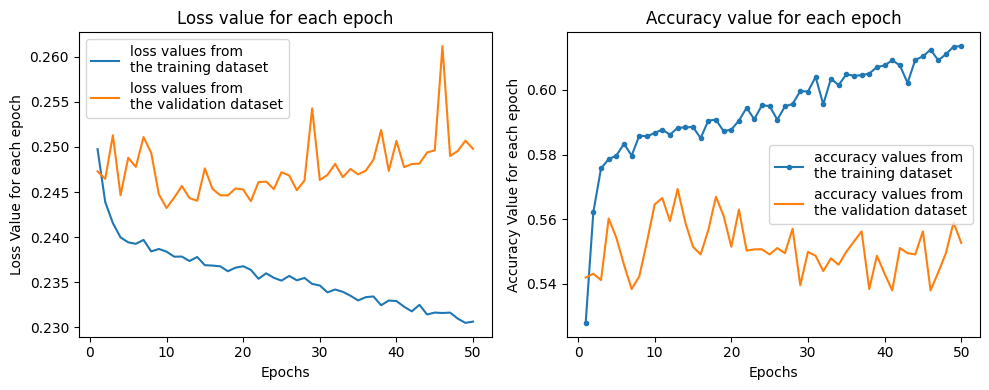

In [22]:
# Define the tuner function to create a TF binary logistic regression model
def model_tuner(hp):
  tf.keras.backend.clear_session()
  tuner = tf.keras.Sequential()

  # Input layer
  tuner.add(tf.keras.Input(shape=(X_train_tf.shape[1],)))   # Input Dim

  # Hidden layers
  for i in range(hp.Int("num_layers", min_value=1, max_value=3)):
    tuner.add(tf.keras.layers.Dense(units=hp.Int(f"units_{i}", min_value=16, max_value=128, step=16),
                                    activation=hp.Choice(f"activation_{i}", values=['relu', 'tanh', 'sigmoid'])))

  # Output layer
  tuner.add(tf.keras.layers.Dense(units=1,                  # Output dim
                                  use_bias=True,            # Use a bias (intercept) param
                                  activation='sigmoid',     # Using sigmoid for binary classification
                                  kernel_initializer='glorot_uniform',
                                  bias_initializer='zeros'))

  # Learning rate tuning
  learning_rate = hp.Float('learning_rate', min_value=0.0001, max_value=0.5, sampling='log')

  # Optimizer tuning
  optimizer_choice = hp.Choice('optimizer', ['adam', 'sgd'])
  if optimizer_choice == 'adam':
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
  elif optimizer_choice == 'sgd':
    optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate)

  # Compile and return the tuner
  tuner.compile(optimizer=optimizer,
                loss=hp.Choice('loss', ['binary_crossentropy', 'mse']),
                metrics=['accuracy'])
  return tuner

# Hyperparameter Tuning
tuner = kt.RandomSearch(model_tuner,
                        objective='val_accuracy',
                        max_trials=10)
tuner.search(X_train_tf, Y_train_tf,
             validation_data=(X_val_tf, Y_val_tf),
             epochs=10,
             verbose=2)
hyperparameters = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f'The best hyperparameters are:\n{hyperparameters}')

# Create and fit the model on the training dataset
model_tf = tuner.hypermodel.build(hyperparameters)
history = model_tf.fit(X_train_tf, Y_train_tf,
                       validation_data=(X_val_tf, Y_val_tf),
                       epochs=50,
                       verbose = False)
print(f"\nAccuracy on the training dataset: {history.history['accuracy'][-1]:.2%}")
print(f"Accuracy on the validation dataset: {history.history['val_accuracy'][-1]:.2%}")

# Generate a plot
fig, ax = plt.subplots(1, 2, figsize=(10,4))

ax[0].plot([i+1 for i in range(len(history.history['loss']))],
           history.history['loss'],
           label='loss values from \nthe training dataset')
ax[0].plot([i+1 for i in range(len(history.history['val_loss']))],
           history.history['val_loss'],
           label='loss values from \nthe validation dataset')
ax[1].plot([i+1 for i in range(len(history.history['accuracy']))],
           history.history['accuracy'],
           label='accuracy values from \nthe training dataset',
           marker='.') # To avoid overlap
ax[1].plot([i+1 for i in range(len(history.history['val_accuracy']))],
           history.history['val_accuracy'],
           label='accuracy values from \nthe validation dataset')

# Add title, axes, and legend
ax[0].set_title('Loss value for each epoch')
ax[1].set_title('Accuracy value for each epoch')
ax[0].set_xlabel('Epochs')
ax[1].set_xlabel('Epochs')
ax[0].set_ylabel('Loss Value for each epoch')
ax[1].set_ylabel('Accuracy Value for each epoch')
ax[0].legend()
ax[1].legend()
plt.tight_layout()
plt.show()

236/236 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

The aggregate accuracy from the training dataset is: 62.48%
The aggregate accuracy from the testing dataset is: 55.32%


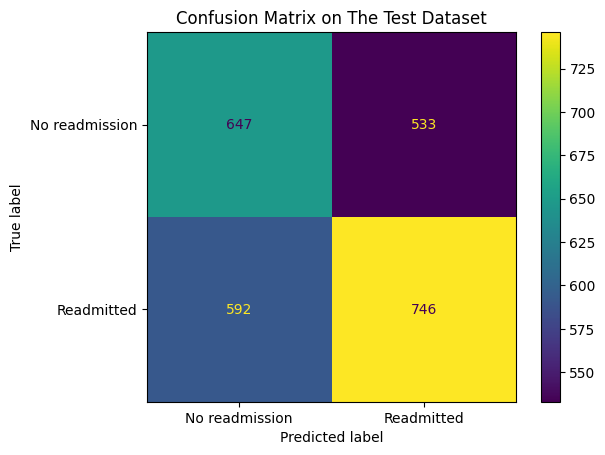

Precisions: 58.33%
Recalls: 55.75%

F1 score: 57.01%


In [23]:
# Calculate the predicted values
Y_train_hat_tf = (model_tf.predict(X_train_tf) >= 0.5).astype(int)
Y_test_hat_tf = (model_tf.predict(X_test_tf) >= 0.5).astype(int)

# Calculate accuracy values on both train and test datasets
accuracy_train_tf = accuracy_score(Y_train_tf, Y_train_hat_tf)
accuracy_test_tf = accuracy_score(Y_test_tf, Y_test_hat_tf)
print(f'\nThe aggregate accuracy from the training dataset is: {accuracy_train_tf:.2%}')
print(f'The aggregate accuracy from the testing dataset is: {accuracy_test_tf:.2%}')


# Plot the confusion matrix
cm_tf = confusion_matrix(Y_test_tf, Y_test_hat_tf)
disp = ConfusionMatrixDisplay(cm_tf, display_labels=['No readmission', 'Readmitted'])
disp.plot()
plt.grid(False) # Hide the white grid lines
plt.title('Confusion Matrix on The Test Dataset')
plt.show()

# Evaluation from the confusion matrix
precision_tf = precision_score(Y_test_tf, Y_test_hat_tf)    # cm_tf[1][1]/cm_tf[:,1].sum()
recall_tf = recall_score(Y_test_tf, Y_test_hat_tf)          # cm_tf[1][1]/cm_tf[1].sum()
f1_tf = f1_score(Y_test_tf, Y_test_hat_tf)                  # 2 * precision_tf * recall_tf / (precision_tf + recall_tf)
print(f'Precisions: {precision_tf:.2%}')
print(f'Recalls: {recall_tf:.2%}')
print(f'\nF1 score: {f1_tf:.2%}')

## 3. Notebook Exports

#### 3.1 Export the training, validation, and testing datasets

In [24]:
df_train = pd.concat([X_train, Y_train], axis=1).to_csv('../results/train.csv', index=False)
df_val = pd.concat([X_val, Y_val], axis=1).to_csv('../results/val.csv', index=False)
df_test = pd.concat([X_test, Y_test], axis=1).to_csv('../results/test.csv', index=False)

#### 3.2 Export baseline model(s)

In [25]:
joblib.dump(model_tf, '../results/baseline.pkl')

['../results/baseline.pkl']